# Load library

In [1]:
import sys
from os.path import exists

# this is the repository I pulled/downloaded from github: 
CONGA_PATH = r"C:\Users\andre\conga"
# confirm that it's the right level directory (since the repo and library have the same name)
assert exists(CONGA_PATH+'/README.md')
sys.path.append(CONGA_PATH)
import scanpy as sc
import conga
import joblib
import pandas as pd
import scvi
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r"C:\Users\andre\revision")

In [ ]:
# import ipympl
# import matplotlib.collections as mcoll
# from adjustText import adjust_text
# import matplotlib.patheffects as PathEffects

# class DraggableText:
#     def __init__(self, text):
#         self.text = text
#         text.set_picker(True)  # enable pick events on the text
#         self.press = None
#         # connect pick event
#         text.figure.canvas.mpl_connect('pick_event', self.on_pick)

#     def on_pick(self, event):
#         if event.artist is not self.text: return
#         x0, y0 = self.text.get_position()
#         xpress, ypress = event.mouseevent.xdata, event.mouseevent.ydata
#         self.press = (x0, y0, xpress, ypress)
#         # connect motion and release
#         self.cidmotion = self.text.figure.canvas.mpl_connect(
#             'motion_notify_event', self.on_motion)
#         self.cidrelease = self.text.figure.canvas.mpl_connect(
#             'button_release_event', self.on_release)

#     def on_motion(self, event):
#         if self.press is None or event.xdata is None: return
#         x0, y0, xpress, ypress = self.press
#         dx, dy = event.xdata - xpress, event.ydata - ypress
#         self.text.set_position((x0 + dx, y0 + dy))
#         self.text.figure.canvas.draw_idle()

#     def on_release(self, event):
#         # disconnect the motion/release callbacks
#         self.text.figure.canvas.mpl_disconnect(self.cidmotion)
#         self.text.figure.canvas.mpl_disconnect(self.cidrelease)
#         self.press = None

In [3]:
# Nice palette generated by @xuancong84 and @Greg0ry on stack overflow
import math
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.cm import hsv


def generate_colormap(number_of_distinct_colors: int = 80):
    if number_of_distinct_colors == 0:
        number_of_distinct_colors = 80

    number_of_shades = 7
    number_of_distinct_colors_with_multiply_of_shades = int(math.ceil(number_of_distinct_colors / number_of_shades) * number_of_shades)

    # Create an array with uniformly drawn floats taken from <0, 1) partition
    linearly_distributed_nums = np.arange(number_of_distinct_colors_with_multiply_of_shades) / number_of_distinct_colors_with_multiply_of_shades

    # We are going to reorganise monotonically growing numbers in such way that there will be single array with saw-like pattern
    #     but each saw tooth is slightly higher than the one before
    # First divide linearly_distributed_nums into number_of_shades sub-arrays containing linearly distributed numbers
    arr_by_shade_rows = linearly_distributed_nums.reshape(number_of_shades, number_of_distinct_colors_with_multiply_of_shades // number_of_shades)

    # Transpose the above matrix (columns become rows) - as a result each row contains saw tooth with values slightly higher than row above
    arr_by_shade_columns = arr_by_shade_rows.T

    # Keep number of saw teeth for later
    number_of_partitions = arr_by_shade_columns.shape[0]

    # Flatten the above matrix - join each row into single array
    nums_distributed_like_rising_saw = arr_by_shade_columns.reshape(-1)

    # HSV colour map is cyclic (https://matplotlib.org/tutorials/colors/colormaps.html#cyclic), we'll use this property
    initial_cm = hsv(nums_distributed_like_rising_saw)

    lower_partitions_half = number_of_partitions // 2
    upper_partitions_half = number_of_partitions - lower_partitions_half

    # Modify lower half in such way that colours towards beginning of partition are darker
    # First colours are affected more, colours closer to the middle are affected less
    lower_half = lower_partitions_half * number_of_shades
    for i in range(3):
        initial_cm[0:lower_half, i] *= np.arange(0.2, 1, 0.8/lower_half)

    # Modify second half in such way that colours towards end of partition are less intense and brighter
    # Colours closer to the middle are affected less, colours closer to the end are affected more
    for i in range(3):
        for j in range(upper_partitions_half):
            modifier = np.ones(number_of_shades) - initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i]
            modifier = j * modifier / upper_partitions_half
            initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i] += modifier

    return ListedColormap(initial_cm)

(35, 4)


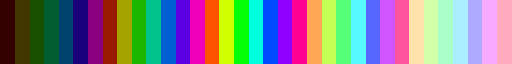

In [4]:
cmap_30=generate_colormap(5*6)
print(cmap_30.colors.shape)
cmap_30

In [5]:
clones_file = 'gut_liver_TRM_clones_without0.tsv'
organism = 'human'
outfile_prefix = 'conga_output_gut_liver_TRM' 

In [6]:
all_nbrs = joblib.load('0813_all_nbrs.pkl')
color_dict_30 = joblib.load('color_dict_30.pkl')
GEX_color_dict = joblib.load('0813_GEX_color_dict.pkl')
nbr_fracs = [0.01, 0.1]
nbr_frac_for_nndists = 0.01

In [7]:
# adata_ab = sc.read_h5ad('250723_gut_liver_TRM_adata_abTCR_conga.h5ad')
adata_ab = sc.read_h5ad('250813_gut_liver_TRM_adata_abTCR_conga.h5ad')

In [8]:
clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values
cmap = plt.get_cmap('tab20')
# colors = adata_ab.obs['celltype_colorcode']
colors = [cmap_30.colors[34-x] for x in clusters_gex_num]
GEX_color_array = colors
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold','axes.linewidth':2})
adata_ab.obs['gex_colors'] = GEX_color_array

C:\Users\andre\AppData\Local\Temp\ipykernel_23948\4288984531.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values


### prepare data to meet conga's standard

In [12]:
adata = sc.read_h5ad(r"D:\Trapecar\250307_gut_liver_blood_ultimate_annotated.h5ad")

In [13]:
adata.obs.columns

Index(['has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a',
       'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes',
       'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff',
       'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type',
       'activation', 'tissue', 'general subtype', 'celltype',
       'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation',
       'major celltype', 'major general subtype', 'Donor ID',
       'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation',
       'cluster+celltype w/ activation',
       'tissue+cluster+celltype w/ activation', 'act_score',
       'donor+tissue+celltype w/ activation'],
      dtype='object')

In [14]:
adata.obs['va'] = adata.obs['TRAV']
adata.obs['ja'] = adata.obs['TRAJ'] 
adata.obs['vb'] = adata.obs['TRBV'] 
adata.obs['jb'] = adata.obs['TRBJ'] 

In [15]:
adata_TCR = adata[adata.obs['chain_pairing'].isin(["single pair", "extra VJ","extra VDJ","two full chains"]),:]

In [16]:
adata_ab = adata_TCR[adata_TCR.obs['general type'].isin(['TCRab CD4','TCRab CD8aa','TCRab CD8ab']),:]

In [17]:
adata_ab.obs['clone_code'] = adata_ab.obs['TRAV'].astype(str).map(str)+' '+adata_ab.obs['TRBV'].astype(str).map(str)+' '+adata_ab.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab.obs['cdr3b'].astype(str).map(str)

C:\Users\andre\AppData\Local\Temp\ipykernel_14544\3965735778.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ab.obs['clone_code'] = adata_ab.obs['TRAV'].astype(str).map(str)+' '+adata_ab.obs['TRBV'].astype(str).map(str)+' '+adata_ab.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab.obs['cdr3b'].astype(str).map(str)


#### prepare for the TCRdist

In [18]:
clone_df = adata_ab.obs[[ 'batch','TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3a', 'cdr3b','clone_code']]

In [86]:
clone_counts = clone_df.groupby(['batch','clone_code']).size().reset_index(name='clone_size')
clone_counts[['TRAV','TRBV','cdr3a','cdr3b']] = clone_counts['clone_code'].str.split(' ', expand=True)

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\2577822773.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_counts = clone_df.groupby(['batch','clone_code']).size().reset_index(name='clone_size')


In [82]:
clone_df.groupby(['batch', 'clone_code'])['TRAJ'].apply(lambda x: len(set(x))).sort_values(ascending=False)
#Just to confirm Js are unique to our clonotype strategy

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\2966889109.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_df.groupby(['batch', 'clone_code'])['TRAJ'].apply(lambda x: len(set(x))).sort_values(ascending=False)


batch  clone_code                                      
5      TRAV9-2 TRBV9 CALSPYGGATNKLIF CASSVGTGGPNEQFF       1.0
3      TRAV1-1 TRBV10-2 CAGDNYGQNFVF CASRAGGVTEAFF         1.0
       TRAV1-1 TRBV10-2 CAVRDQLPAGKSTF CASRGGGGNNEQFF      1.0
       TRAV1-1 TRBV10-3 CAGGGSAAGNKLTF CAISERPGTENEKLFF    1.0
       TRAV1-1 TRBV10-3 CAGMDSNYQLIW CAISDDRGHRNYGYTF      1.0
                                                          ... 
5      TRAV9-2 TRBV9 CALSPYNFNKFYF CASSVEVVPHEQYF          NaN
       TRAV9-2 TRBV9 CALSSNQAGTALIF CASSMDRGHNEQFF         NaN
       TRAV9-2 TRBV9 CALSTLDSSYKLIF CASSVEGSGGPNIQYF       NaN
       TRAV9-2 TRBV9 CALYTGGFKTIF CASSVSGLAGGSYNEQFF       NaN
       TRAV9-2 TRBV9 CASETSGSRLTF CASSVGRTANIQYF           NaN
Name: TRAJ, Length: 56421, dtype: float64

In [93]:
Jmap = clone_df[['TRAJ','TRBJ','clone_code']].drop_duplicates()
Jmap = Jmap.set_index('clone_code')
Jmap_adict = Jmap['TRAJ'].to_dict()
Jmap_bdict = Jmap['TRBJ'].to_dict()

In [94]:
clone_counts['ja_gene'] =clone_counts['clone_code'].replace(Jmap_adict)
clone_counts['jb_gene'] =clone_counts['clone_code'].replace(Jmap_bdict)

In [95]:
clone_counts

,batch,clone_code,clone_size,TRAV,TRBV,cdr3a,cdr3b,ja_gene,jb_gene
0,3,TRAV1-1 TRBV10-2 CAGDNYGQNFVF CASRAGGVTEAFF,1,TRAV1-1,TRBV10-2,CAGDNYGQNFVF,CASRAGGVTEAFF,TRAJ26,TRBJ1-1
1,3,TRAV1-1 TRBV10-2 CAVRDQLPAGKSTF CASRGGGGNNEQFF,1,TRAV1-1,TRBV10-2,CAVRDQLPAGKSTF,CASRGGGGNNEQFF,TRAJ27,TRBJ2-1
2,3,TRAV1-1 TRBV10-2 CAVREGSSNTGKLIF CASSDPSGAKEETQYF,0,TRAV1-1,TRBV10-2,CAVREGSSNTGKLIF,CASSDPSGAKEETQYF,TRAJ37,TRBJ2-5
3,3,TRAV1-1 TRBV10-3 CAGGGSAAGNKLTF CAISERPGTENEKLFF,1,TRAV1-1,TRBV10-3,CAGGGSAAGNKLTF,CAISERPGTENEKLFF,TRAJ17,TRBJ1-4
4,3,TRAV1-1 TRBV10-3 CAGMDSNYQLIW CAISDDRGHRNYGYTF,1,TRAV1-1,TRBV10-3,CAGMDSNYQLIW,CAISDDRGHRNYGYTF,TRAJ33,TRBJ1-2
...,...,...,...,...,...,...,...,...,...
56416,5,TRAV9-2 TRBV9 CALSPYNFNKFYF CASSVEVVPHEQYF,0,TRAV9-2,TRBV9,CALSPYNFNKFYF,CASSVEVVPHEQYF,TRAJ21,TRBJ2-7
56417,5,TRAV9-2 TRBV9 CALSSNQAGTALIF CASSMDRGHNEQFF,0,TRAV9-2,TRBV9,CALSSNQAGTALIF,CASSMDRGHNEQFF,TRAJ15,TRBJ2-1
56418,5,TRAV9-2 TRBV9 CALSTLDSSYKLIF CASSVEGSGGPNIQYF,0,TRAV9-2,TRBV9,CALSTLDSSYKLIF,CASSVEGSGGPNIQYF,TRAJ12,TRBJ2-4
56419,5,TRAV9-2 TRBV9 CALYTGGFKTIF CASSVSGLAGGSYNEQFF,0,TRAV9-2,TRBV9,CALYTGGFKTIF,CASSVSGLAGGSYNEQFF,TRAJ9,TRBJ2-1


In [51]:
clone_replace_dict = clone_counts['clone_code'].drop_duplicates().reset_index().set_index('clone_code')['index'].to_dict()

In [96]:
clone_counts['clone_code'] = clone_counts['clone_code'].replace(clone_replace_dict)

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\3147651609.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clone_counts['clone_code'] = clone_counts['clone_code'].replace(clone_replace_dict)


In [ ]:
clone_counts['clone_code'] = 'clonotype'+clone_counts['clone_code'].astype(str).map(str)

In [103]:
clone_counts = clone_counts.rename(columns = {'batch':'subject',
                                              'clone_code':'clone_id',
                                              'TRAV':'va_gene',
                                              'TRBV':'vb_gene',
                                              'TRAJ':'ja_gene',
                                              'TRBJ':'jb_gene'})

In [108]:
clone_counts

,subject,clone_id,clone_size,va_gene,vb_gene,cdr3a,cdr3b,ja_gene,jb_gene
0,3,clonotype0,1,TRAV1-1,TRBV10-2,CAGDNYGQNFVF,CASRAGGVTEAFF,TRAJ26,TRBJ1-1
1,3,clonotype1,1,TRAV1-1,TRBV10-2,CAVRDQLPAGKSTF,CASRGGGGNNEQFF,TRAJ27,TRBJ2-1
2,3,clonotype2,0,TRAV1-1,TRBV10-2,CAVREGSSNTGKLIF,CASSDPSGAKEETQYF,TRAJ37,TRBJ2-5
3,3,clonotype3,1,TRAV1-1,TRBV10-3,CAGGGSAAGNKLTF,CAISERPGTENEKLFF,TRAJ17,TRBJ1-4
4,3,clonotype4,1,TRAV1-1,TRBV10-3,CAGMDSNYQLIW,CAISDDRGHRNYGYTF,TRAJ33,TRBJ1-2
...,...,...,...,...,...,...,...,...,...
56416,5,clonotype18802,0,TRAV9-2,TRBV9,CALSPYNFNKFYF,CASSVEVVPHEQYF,TRAJ21,TRBJ2-7
56417,5,clonotype18803,0,TRAV9-2,TRBV9,CALSSNQAGTALIF,CASSMDRGHNEQFF,TRAJ15,TRBJ2-1
56418,5,clonotype18804,0,TRAV9-2,TRBV9,CALSTLDSSYKLIF,CASSVEGSGGPNIQYF,TRAJ12,TRBJ2-4
56419,5,clonotype18805,0,TRAV9-2,TRBV9,CALYTGGFKTIF,CASSVSGLAGGSYNEQFF,TRAJ9,TRBJ2-1


In [109]:
clone_counts.to_csv('gut_liver_TRM_clones_with0.tsv',sep = '\t')

In [117]:
clone_counts_clean = clone_counts[clone_counts['clone_size']>0]

# we don't know such information from 10X. Default to *01 to obtain the clustering result
for col in ['va_gene','vb_gene','ja_gene','jb_gene']:
    clone_counts_clean[col] = clone_counts_clean[col].apply(lambda x: x+'*01')
clone_counts_clean
clone_counts_clean.to_csv(clones_file,sep = '\t')

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\85995449.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clone_counts_clean[col] = clone_counts_clean[col].apply(lambda x: x+'*01')


In [118]:
conga.preprocess.make_tcrdist_kernel_pcs_file_from_clones_file(clones_file, organism)

compute tcrdist distance matrix for 18807 clonotypes
Using Python TCRdist calculator. Consider compiling C++ calculator for faster perfomance.
running KernelPCA with None kernel distance matrix shape= (18807, 18807) D.max()= 901.0 force_Dmax= None
writing TCRdist kernel PCs to outfile: gut_liver_TRM_clones_without0_AB.dist_50_kpcs


### retrive mapping dict

In [9]:
tcr_pca = pd.read_csv('gut_liver_TRM_clones_without0_AB.dist_50_kpcs',sep = ' ',index_col = 1,header = None)
del tcr_pca[0]
tcr_pca.index.names = ['clonotypes']
tcr_pca.columns = ['PC_'+str(i-2) for i in tcr_pca.columns]

In [10]:
clone_counts= pd.read_csv('gut_liver_TRM_clones_with0.tsv',sep = '\t',index_col = 0)
clone_counts_clean = pd.read_csv(clones_file,sep = '\t',index_col = 0)

In [11]:
temp_dict_df = clone_counts[clone_counts['clone_size']>0][['clone_id','va_gene','vb_gene','cdr3a','cdr3b']]
temp_dict_df['clone_code'] = temp_dict_df['va_gene'].astype(str).map(str) + ' ' + temp_dict_df['vb_gene'].astype(str).map(str) + ' ' + temp_dict_df['cdr3a'].astype(str).map(str) + ' ' + temp_dict_df['cdr3b'].astype(str).map(str)
clone_replace_dict = temp_dict_df[['clone_id','clone_code']].set_index('clone_code').sort_index()['clone_id'].to_dict()
# clone_counts[['va_gene','vb_gene','cdr3a','cdr3b']]

In [ ]:
# adata_ab.write('250721_gut_liver_TRM_adata_abTCR.h5ad')

### organize adata_ab

#### basic preprocessing

In [22]:
adata_ab.uns['organism'] = organism

In [23]:
adata_ab.obs['subject_id'] = adata_ab.obs['batch']

In [24]:
adata_ab.obs['clone_id'] = adata_ab.obs['clone_code']
adata_ab.obs['clone_id'] = adata_ab.obs['clone_id'].replace(clone_replace_dict)
# adata_ab.obs['clone_id'] = 'clonotype' + adata_ab.obs['clone_id'].astype(str).map(str)

In [26]:
adata_ab.obs['clone_id']

AAACCTGAGCGCCTCA-1-3-PB     clonotype16056
AAACCTGAGGCAAAGA-1-3-PB     clonotype15288
AAACCTGAGTTATCGC-1-3-PB      clonotype5937
AAACCTGCAAGCGATG-1-3-PB      clonotype9202
AAACCTGGTTACGTCA-1-3-PB      clonotype4064
                                 ...      
TTTGTCAAGAACTGTA-1-5-IEL    clonotype10944
TTTGTCAAGGGAGTAA-1-5-IEL    clonotype12287
TTTGTCAAGTTGTCGT-1-5-IEL    clonotype10734
TTTGTCACAATGACCT-1-5-IEL     clonotype3531
TTTGTCACATCGATTG-1-5-IEL     clonotype9388
Name: clone_id, Length: 26297, dtype: object

In [28]:
adata_ab.obsm['X_pca_tcr'] = tcr_pca.loc[adata_ab.obs['clone_id'],:].values

In [29]:
for col in ['va','vb','ja','jb']:
    adata_ab.obs[col] = adata_ab.obs[col].apply(lambda x: x+'*01')

In [35]:
nucseq= pd.read_csv(r'C:\Users\andre\Documents\GitHub\gut-liver-TRM\Revision\refined_id_mapping\nucseq.csv',index_col = 0)

In [37]:
adata_ab.obs['cdr3a_nucseq'] = nucseq['cdr3a_nucseq']
adata_ab.obs['cdr3b_nucseq'] = nucseq['cdr3b_nucseq']

In [39]:
adata_ab.X = adata_ab.layers['counts']

In [40]:
# adata_ab.obsm['X_pca_gex'] = adata_ab.obsm['X_pca']
# adata_ab.obsm['X_gex_2d'] = adata_ab.obsm['X_umap']
adata_ab.obs['clusters_gex'] = adata_ab.obs['tissue+celltype']
# adata_ab.obs.groupby('tissue+celltype').ngroup().astype('str')
adata_ab.obs['clusters_gex'].values.categories.shape

(29,)

In [41]:
# adata_ab.write('250721_gut_liver_TRM_adata_abTCR_conga_input.h5ad')
# adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga_input.h5ad')
adata_ab.write('250813_gut_liver_TRM_adata_abTCR_conga_input.h5ad')

In [43]:
adata_ab = conga.preprocess.filter_and_scale( 
    adata_ab, 
    min_genes_per_cell=200,
    max_genes_per_cell=6000,
    max_percent_mito=0.5,
)

filtered out 0 cells with more than 6000 genes
filtered out 0 cells with more than 0.5 percent mito
unable to find feature_types varname
Index(['A1BG', 'A1BG-AS1', 'A2M', 'A2M-AS1', 'AAAS', 'AACS', 'AAGAB', 'AAK1',
       'AAMDC', 'AAMP',
       ...
       'ZUP1', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11B',
       'ZYX', 'ZZEF1'],
      dtype='object', length=15553)


c:\users\andre\conga\conga\preprocess.py:548: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\preprocessing\_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


excluding 117 TR genes (85 variable)
excluding 11 sexlinked genes
total of 1215 variable genes (26297, 15553)
Normalize and logging matrix...
unable to find feature_types varname
Index(['A2M', 'ABCA1', 'ABCB1', 'ABCC4', 'ABI3', 'AC002331.1', 'AC004832.6',
       'AC005083.1', 'AC007384.1', 'AC007952.4',
       ...
       'ZFP36', 'ZFP36L1', 'ZFP36L2', 'ZNF165', 'ZNF267', 'ZNF331', 'ZNF683',
       'ZNF80', 'ZSWIM6', 'ZYX'],
      dtype='object', length=1215)
normalize_and_log_the_raw_matrix: adata.raw.X.max()=  2567.0


#### after preprocessing, starting from here

In [57]:
adata_ab = conga.preprocess.reduce_to_single_cell_per_clone(adata_ab)

adata_ab

compute pca to find rep cell for each clone (26297, 1215)
retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present
num_clones: 18807
normalize_and_log_the_raw_matrix:: matrix is already logged
choose representative cell for clone: 0 18807 (26297, 1215)
choose representative cell for clone: 1000 18807 (26297, 1215)
choose representative cell for clone: 2000 18807 (26297, 1215)
choose representative cell for clone: 3000 18807 (26297, 1215)
choose representative cell for clone: 4000 18807 (26297, 1215)
choose representative cell for clone: 5000 18807 (26297, 1215)
choose representative cell for clone: 6000 18807 (26297, 1215)
choose representative cell for clone: 7000 18807 (26297, 1215)
choose representative cell for clone: 8000 18807 (26297, 1215)
choose representative cell for clone: 9000 18807 (26297, 1215)
choose representative cell for clone: 10000 18807 (26297, 1215)
choose representative cell for clone: 11000 18807 (26297, 1215)
choose representative 

c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present


AnnData object with n_obs × n_vars = 18807 × 1215
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'va', 'ja', 'vb', 'jb', 'clone_code', 'subject_id', 'clone_id', 'cdr3a_nucseq', 'cdr3b_nucseq', 'clusters_gex', 'percent_mito', 'sample_id', '_scvi_batch', '_scvi_labels', 'clone_sizes', 'gex_variation'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', '

In [58]:
adata_ab.X = adata_ab.layers['counts']
adata_ab.obs['sample_id'] = adata_ab.obs['batch'].astype(str).map(str) +'_'+ adata_ab.obs['tissue'].astype(str).map(str)

In [ ]:
scvi.model.SCVI.setup_anndata(adata_ab, batch_key='sample_id')
model = scvi.model.SCVI(adata_ab, n_layers=2, n_latent=30)
model.train(max_epochs=200)
model.save("250814_scVI", overwrite=True)
adata_ab.obsm["X_scVI"] = model.get_latent_representation()

C:\Users\andre\AppData\Local\Temp\ipykernel_23948\1313240457.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_sup_umap = mapper.fit_transform(adata_ab.obsm["X_scVI"], adata_ab.obs.groupby(['tissue+celltype']).ngroup().astype(int).values)
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


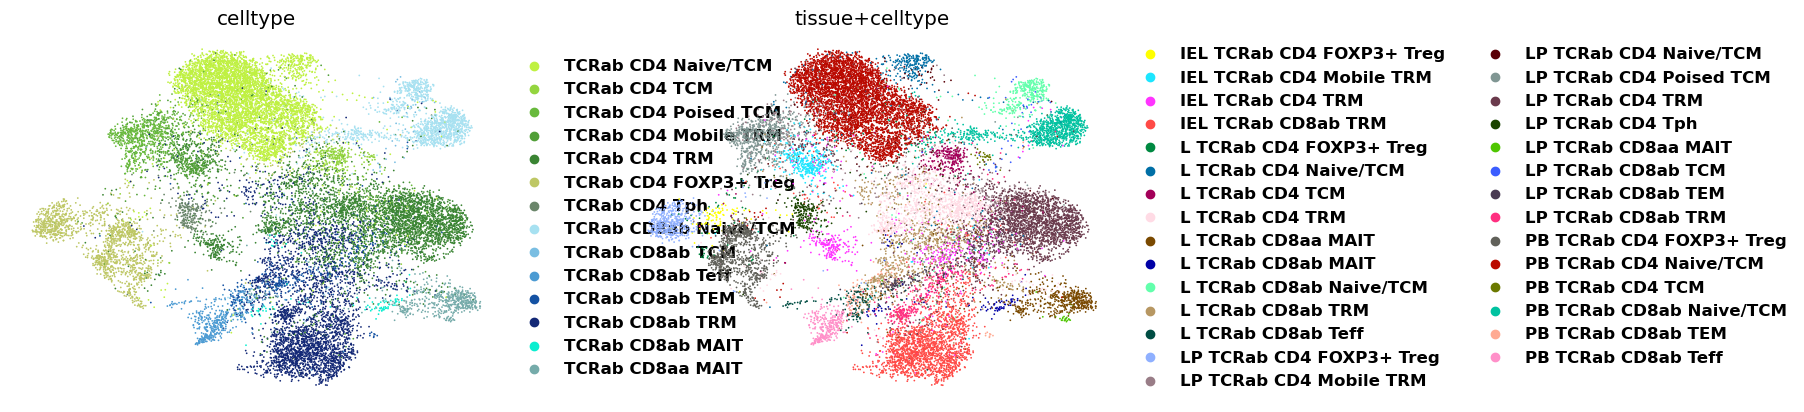

In [30]:
import umap
mapper = umap.UMAP(n_neighbors=30, min_dist=0.5,
                target_metric='categorical', target_weight=0.2, random_state=0)
X_sup_umap = mapper.fit_transform(adata_ab.obsm["X_scVI"], adata_ab.obs.groupby(['tissue+celltype']).ngroup().astype(int).values)
adata_ab.obsm['X_umap'] = X_sup_umap
# Visualize datasets integrated by scVI
sc.pl.umap(adata_ab, color=['celltype','tissue+celltype'], frameon=False)
# sc.tl.paga(adata_ab,groups = 'tissue+celltype')
# sc.pl.paga(adata_ab, threshold = 0.5)
# sc.tl.umap(adata_ab, min_dist = 0.2, spread = 1)
# sc.pl.umap(adata_ab, color = ['clusters_gex','batch'])

In [31]:
X_umap = adata_ab.obsm['X_umap']
X_scVI = adata_ab.obsm['X_scVI']

In [61]:
adata_ab = conga.preprocess.cluster_and_tsne_and_umap( adata_ab )

computing X_pca_gex using sc.tl.pca
running 1D UMAP gex


c:\users\andre\conga\conga\preprocess.py:784: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=cluster_key_added)


ran leiden clustering: leiden_gex
running 1D UMAP tcr
ran leiden clustering: leiden_tcr


In [9]:
# conga.preprocess.calc_tcrdist_nbrs_umap_clusters_cpp(adata_ab,10,make_1d_umaps=True,
#                                                      tmpfile_prefix=r"C:\Users\andre\conga\tcrdist_cpp\tmp_gut_liver",
#                                                      clustering_method='leiden',
#                                                      clustering_resolution=1)
#jump out and run the cmd in wsl command line because of the compling issue with windows
#dos2unix /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_tcrs.tsv
#/mnt/c/Users/andre/conga/tcrdist_cpp/bin/find_neighbors   -f /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_tcrs.tsv   -n 10   -d /mnt/c/Users/andre/conga/tcrdist_cpp/db/tcrdist_info_human.txt   -o /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_calc_tcrdist
#and move file back to wd



# #I just adapted this from conga cuz it process the tcr info separately on their TCRdist
# tag = 'tcr'
# adata_ab.obsm['X_pca'] = adata_ab.obsm['X_pca_' + tag]
# n_pcs = adata_ab.obsm['X_pca'].shape[1]

# # Compute neighbors using TCR PCs
# sc.pp.neighbors(adata_ab, n_neighbors=10, n_pcs=n_pcs)

# # Run UMAP
# sc.tl.umap(adata_ab, min_dist=0.5, spread=1.0)
# adata_ab.obsm['X_umap_' + tag] = adata_ab.obsm['X_umap']

# # Run 1D UMAP (optional)
# sc.tl.umap(adata_ab, n_components=1)
# adata_ab.obsm[f'X_{tag}_1d'] = adata_ab.obsm['X_umap']

# # Run Leiden clustering
# sc.tl.leiden(adata_ab, resolution=1.0, key_added='leiden_' + tag)
# adata_ab.obs['clusters_' + tag] = adata_ab.obs['leiden_' + tag].astype(int)

# adata_ab.obsm['X_{}_2d'.format(tag)] = adata_ab.obsm['X_umap_'+tag]

C:\Users\andre\AppData\Local\Temp\ipykernel_28572\1448302590.py:27: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_ab, resolution=1.0, key_added='leiden_' + tag)


In [104]:
# celltype_color_dict = pd.DataFrame([adata_ab.obs['celltype'].values.categories,adata_ab.uns['celltype_colors']]).T.set_index(0)[1].to_dict()
# adata_ab.obs['celltype_colorcode'] = adata_ab.obs['celltype'].replace(celltype_color_dict)

C:\Users\andre\AppData\Local\Temp\ipykernel_23812\1797453036.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_ab.obs['celltype_colorcode'] = adata_ab.obs['celltype'].replace(celltype_color_dict)


In [62]:
adata_ab.obsm['X_pca_gex'] = X_scVI
adata_ab.obsm['X_gex_2d'] = X_umap
adata_ab.obs['clusters_gex'] = adata_ab.obs['tissue+celltype']
# adata_ab.obs.groupby('tissue+celltype').ngroup().astype('str')
adata_ab.obs['clusters_gex'].values.categories.shape

(29,)

C:\Users\andre\AppData\Local\Temp\ipykernel_23948\1108244951.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values


Text(0.5, 1.0, 'TCR UMAP colored by TCR clusters')

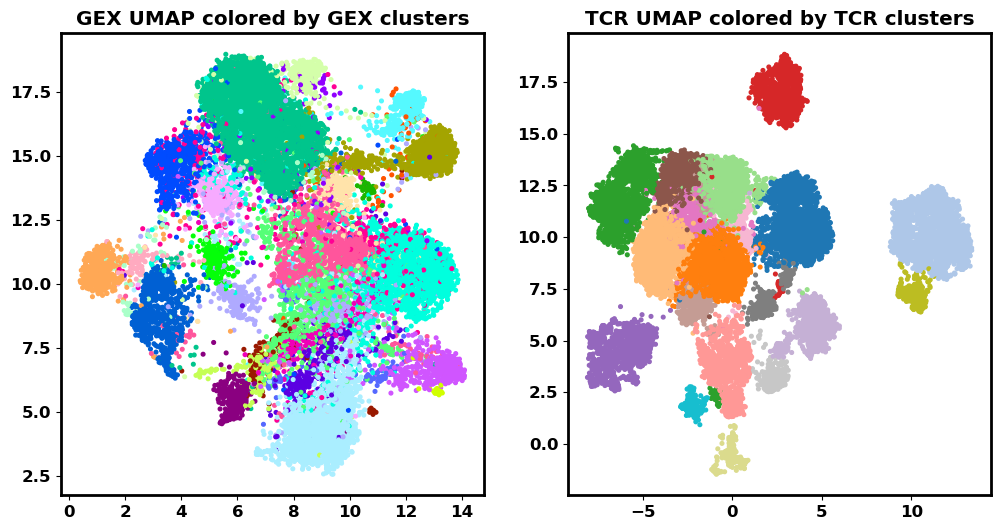

In [33]:
plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata_ab.obsm['X_gex_2d']
clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values
cmap = plt.get_cmap('tab20')
# colors = adata_ab.obs['celltype_colorcode']
colors = [cmap_30.colors[34-x] for x in clusters_gex_num]
GEX_color_array = colors

plt.scatter( xy[:,0], xy[:,1], c=colors,s =7)
# plt.legend()
plt.title('GEX UMAP colored by GEX clusters',fontweight = 'bold')

plt.subplot(122)
xy = adata_ab.obsm['X_tcr_2d']
clusters = np.array(adata_ab.obs['clusters_tcr'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors,s =7)
plt.title('TCR UMAP colored by TCR clusters',fontweight = 'bold')

In [34]:
color_df = pd.DataFrame(adata_ab.obs['tissue+celltype'])
color_df['clusters_gex_num'] = clusters_gex_num
color_df['tissue_celltype_colors'] = GEX_color_array
color_df['cluster_legend'] = color_df['clusters_gex_num'].astype(str).map(str) + ': ' + color_df['tissue+celltype'].astype(str).map(str)    
color_df = color_df.drop_duplicates(subset = 'cluster_legend')
color_df = color_df.set_index('cluster_legend')
color_dict_30 = color_df['tissue_celltype_colors'].sort_index().to_dict()
color_dict_30

{'0: IEL TCRab CD4 FOXP3+ Treg': array([1.        , 0.66666667, 0.75196084, 1.        ]),
 '10: L TCRab CD8ab Naive/TCM': array([0.33333333, 0.9772078 , 1.        , 1.        ]),
 '11: L TCRab CD8ab TRM': array([0.33333333, 1.        , 0.46691265, 1.        ]),
 '12: L TCRab CD8ab Teff': array([0.77107754, 1.        , 0.33333333, 1.        ]),
 '13: LP TCRab CD4 FOXP3+ Treg': array([1.        , 0.65759836, 0.33333333, 1.        ]),
 '14: LP TCRab CD4 Mobile TRM': array([1.        , 0.        , 0.58014755, 1.        ]),
 '15: LP TCRab CD4 Naive/TCM': array([0.5628663, 0.       , 1.       , 1.       ]),
 '16: LP TCRab CD4 Poised TCM': array([0.        , 0.29411985, 1.        , 1.        ]),
 '17: LP TCRab CD4 TRM': array([0.       , 1.       , 0.8720566, 1.       ]),
 '18: LP TCRab CD4 Tph': array([0.01580815, 1.        , 0.0308837 , 1.        ]),
 '19: LP TCRab CD8aa MAIT': array([0.81874882, 1.        , 0.        , 1.        ]),
 '1: IEL TCRab CD4 Mobile TRM': array([0.97009771, 0.6666

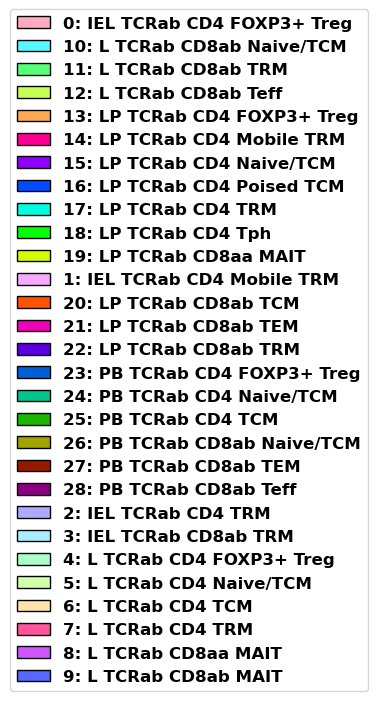

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=celltype)
    for celltype, color in color_dict_30.items()
]

# Create figure and add legend
plt.figure(figsize=(4, 2))
plt.legend(handles=legend_elements, loc='center', frameon=True)
plt.axis('off')  # Hide axes
# plt.title("Cell Type Color Legend")
plt.show()

In [66]:
joblib.dump(color_dict_30, 'color_dict_30.pkl')
# color_dict_30 = joblib.load('color_dict_30.pkl')

['color_dict_30.pkl']

Text(0.5, 1.0, 'GEX UMAP colored by TCR clusters')

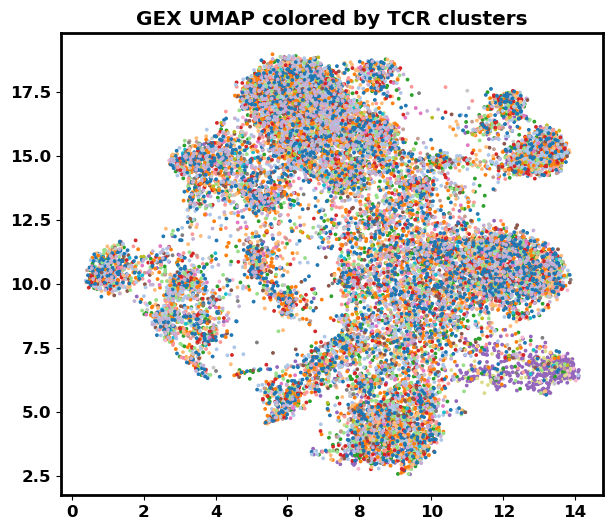

In [36]:
plt.figure(figsize=(7,6))
xy = adata_ab.obsm['X_gex_2d']
clusters = np.array(adata_ab.obs['clusters_tcr'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors,s=3)
plt.title('GEX UMAP colored by TCR clusters',fontweight = 'bold')

In [39]:
del adata_ab.obs['gex_colors']
adata_ab.write('250828_gut_liver_TRM_adata_abTCR_conga.h5ad')
# adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga.h5ad')

In [105]:
# these are the nbrhood sizes, as a fraction of the entire dataset:
nbr_fracs = [0.01] # well this is just giving you the options for nbrhood size, it will go through all and store the result.
# and the craziest thing is that it will select the minimum conga score for which ever these nbr fracs produce
# yet visualizing is done with a fixed nbrhood size

# we use this nbrhood size for computing the nndists
nbr_frac_for_nndists = 0.01

all_nbrs, nndists_gex, nndists_tcr = conga.preprocess.calc_nbrs(
    adata_ab, nbr_fracs, also_calc_nndists=True, nbr_frac_for_nndists=nbr_frac_for_nndists)

# stash these in obs array, they are used in a few places...
# RR: no at least not in their tutorial
adata_ab.obs['nndists_gex'] = nndists_gex
adata_ab.obs['nndists_tcr'] = nndists_tcr
# adata_ab.uns['all_nbrs'] = all_nbrs
conga.preprocess.setup_tcr_cluster_names(adata_ab) #stores in adata_ab.uns

retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present
allocating memory for 3535716 gex nbrs
allocated 14142864 bytes memory id= 2524574572080
allocating memory for 3535716 tcr nbrs
allocated 14142864 bytes memory id= 2524574571696
compute D gex batch= 0 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: gex batch= 0 nbr_frac= 0.01
compute D tcr batch= 0 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: tcr batch= 0 nbr_frac= 0.01
compute D gex batch= 1 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: gex batch= 1 nbr_frac= 0.01
compute D tcr batch= 1 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: tcr batch= 1 nbr_frac= 0.01
compute D gex batch= 2 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: gex batch= 2 nbr_frac= 0.01
compute D tcr batch= 2 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: tcr batch= 2 nbr_frac= 0.01
compute D gex batch= 3 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: gex batch= 3 n

In [106]:
joblib.dump(all_nbrs, '0828_all_nbrs.pkl')
# all_nbrs = joblib.load('all_nbrs.pkl')

['0828_all_nbrs.pkl']

In [108]:
del adata_ab.obs['gex_colors']
adata_ab.write('C:/Users/andre/250828_gut_liver_TRM_adata_abTCR_conga.h5ad')
# adata_ab = sc.read_h5ad('250813_gut_liver_TRM_adata_abTCR_conga.h5ad')

### now conga is comparing the TCR graph and GEX graph

In [109]:
results = conga.correlations.run_graph_vs_graph(
    adata_ab, all_nbrs, outfile_prefix='C:/Users/andre/0828_'+outfile_prefix)
results.head()

retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present
find_neighbor_neighbor_interactions:


c:\users\andre\conga\conga\correlations.py:111: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[double_nbrs])/overlap,


find_neighbor_cluster_interactions:


c:\users\andre\conga\conga\correlations.py:189: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[same_cluster_nbrs])/overlap


find_neighbor_cluster_interactions:


c:\users\andre\conga\conga\correlations.py:189: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[same_cluster_nbrs])/overlap


saved graph_vs_graph results to tsvfile: C:/Users/andre/0828_conga_output_gut_liver_TRM_graph_vs_graph.tsv


c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\a

,conga_score,num_neighbors_gex,num_neighbors_tcr,overlap,overlap_corrected,mait_fraction,clone_index,nbr_frac,graph_overlap_type,cluster_size,gex_cluster,tcr_cluster,va,ja,cdr3a,vb,jb,cdr3b
904,3.501956e-99,NaN,188.0,136,87,0.992647,828,0.01,gex_cluster_vs_tcr_nbr,541.0,8,17,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV20-1*01,TRBJ2-5*01,CSARAGGPQETQYF
896,1.781990e-98,NaN,188.0,135,88,0.985185,820,0.01,gex_cluster_vs_tcr_nbr,561.0,8,17,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV20-1*01,TRBJ1-4*01,CSAHSGQGESEKLFF
909,6.987791e-97,NaN,188.0,140,85,0.992857,833,0.01,gex_cluster_vs_tcr_nbr,561.0,8,17,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV20-1*01,TRBJ2-5*01,CSARLAGGQETQYF
906,1.393286e-93,NaN,188.0,130,85,0.992308,830,0.01,gex_cluster_vs_tcr_nbr,541.0,8,17,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV20-1*01,TRBJ2-5*01,CSARDIHRELETQYF
897,1.875175e-91,NaN,188.0,136,83,1.000000,821,0.01,gex_cluster_vs_tcr_nbr,571.0,8,17,TRAV1-2*01,TRAJ33*01,CAVMDSNYQLIW,TRBV20-1*01,TRBJ1-5*01,CSASLGTGESQPQHF


C:\Users\andre\AppData\Local\Temp\ipykernel_23948\1098599648.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
C:\Users\andre\AppData\Local\Temp\ipykernel_23948\1098599648.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))


(np.float64(-9.183576679229736),
 np.float64(14.454902744293213),
 np.float64(-2.4888642549514772),
 np.float64(19.865225625038146))

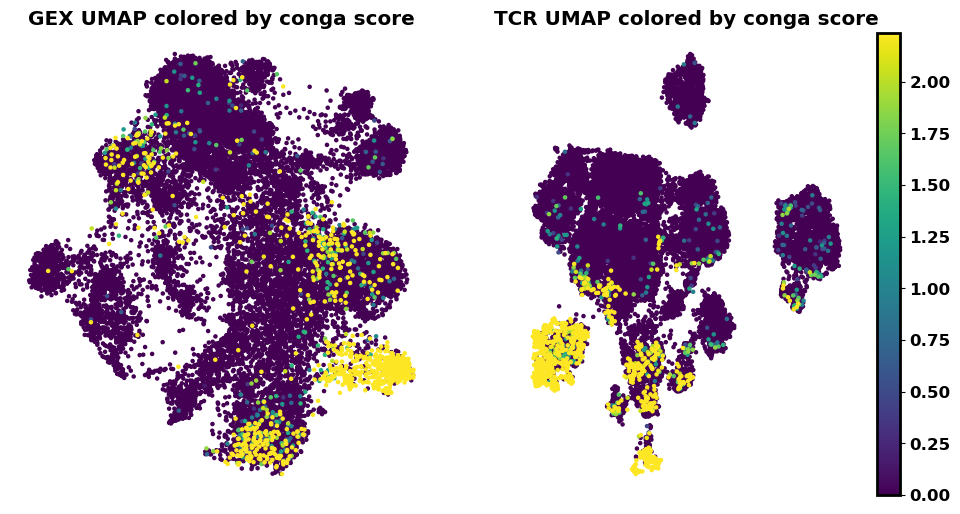

In [ ]:
#put the conga hits on top
conga_scores = adata_ab.obs['conga_scores']
colors = np.sqrt(np.maximum(-1*np.log10(conga_scores),0.0))
reorder = np.argsort(colors)

plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata_ab.obsm['X_gex_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5)) #that is, any conga score above ~0.00058 will be the max color
plt.title('GEX UMAP colored by conga score',fontweight = 'bold')
plt.axis('off')

plt.subplot(122)
xy = adata_ab.obsm['X_tcr_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
plt.colorbar()
plt.title('TCR UMAP colored by conga score',fontweight = 'bold')
plt.axis('off')

In [112]:
adata_ab.obs['clusters_gex'] = clusters_gex_num

In [113]:
adata_ab.obs['clusters_gex']

ATCCACCAGCGCCTCA-1-3-LP     17
CCATGTCTCGCCAAAT-1-3-IEL     3
ATCTACTCACTTCGAA-1-3-LP     17
GATGAAACACTTCGAA-1-3-LP     16
TTCTCAAAGTCTTGCA-1-4-IEL     3
                            ..
GGCTGGTTCCTTGCCA-1-3-LP     16
CAGGTGCAGTTGAGAT-1-3-PB     24
GACCTGGTCACAGTAC-1-3-IEL     1
TACCTATGTTCCGTCT-1-3-IEL     2
GGGACCTAGCTAGTGG-1-5-IEL     3
Name: clusters_gex, Length: 18807, dtype: int64

In [114]:
adata_ab.obs['gex_colors'] = GEX_color_array
GEX_color_dict = adata_ab.obs[['clusters_gex','gex_colors']].set_index('clusters_gex')['gex_colors'].sort_index().to_dict()
GEX_color_dict

{0: array([1.        , 0.66666667, 0.75196084, 1.        ]),
 1: array([0.97009771, 0.66666667, 1.        , 1.        ]),
 2: array([0.68443566, 0.66666667, 1.        , 1.        ]),
 3: array([0.66666667, 0.93455973, 1.        , 1.        ]),
 4: array([0.66666667, 1.        , 0.78750016, 1.        ]),
 5: array([0.8314946 , 1.        , 0.66666667, 1.        ]),
 6: array([1.        , 0.89056395, 0.66666667, 1.        ]),
 7: array([1.        , 0.33333333, 0.61201002, 1.        ]),
 8: array([0.81666588, 0.33333333, 1.        , 1.        ]),
 9: array([0.33333333, 0.4058837 , 1.        , 1.        ]),
 10: array([0.33333333, 0.9772078 , 1.        , 1.        ]),
 11: array([0.33333333, 1.        , 0.46691265, 1.        ]),
 12: array([0.77107754, 1.        , 0.33333333, 1.        ]),
 13: array([1.        , 0.65759836, 0.33333333, 1.        ]),
 14: array([1.        , 0.        , 0.58014755, 1.        ]),
 15: array([0.5628663, 0.       , 1.       , 1.       ]),
 16: array([0.        

In [111]:
joblib.dump(GEX_color_dict,'0828_GEX_color_dict.pkl')

['0828_GEX_color_dict.pkl']

In [ ]:
# del adata_ab.obs['gex_colors']
adata_ab.write('250828_gut_liver_TRM_adata_abTCR_conga.h5ad')
adata_ab = sc.read_h5ad('250828_gut_liver_TRM_adata_abTCR_conga.h5ad')

making tcr score table, #features= 35


c:\users\andre\conga\conga\correlations.py:977: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction = np.sum(nbrhood_is_mait[ top_indices ] )\


run rank_genes_groups [('none', 17682), ('clp_8_8', 296), ('clp_3_8', 193), ('clp_14_7', 144), ('clp_8_17', 112), ('clp_14_3', 54), ('clp_9_8', 42), ('clp_14_15', 34), ('clp_11_8', 29), ('clp_3_1', 28), ('clp_14_2', 28), ('clp_7_8', 26), ('clp_24_1', 24), ('clp_14_18', 24), ('clp_14_16', 21), ('clp_14_0', 21), ('clp_14_9', 18), ('clp_14_11', 16), ('clp_19_8', 15)]
making cluster logos: 0 18 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png


c:\users\andre\conga\conga\plotting.py:1186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_cells = sum( clone_sizes[x] for x in nodes )


conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_14_11_A.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_14_11_A.png"
conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_14_11_B.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_14_11_B.png"
making cluster logos: 1 18 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png


...

conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_A.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_A.png"
conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_B.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_B.png"
conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_9_8.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_9_8.png"
making cluster logos: 16 18 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png


c:\users\andre\conga\conga\plotting.py:1186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_cells = sum( clone_sizes[x] for x in nodes )


conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_17_A.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_17_A.png"
conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_17_B.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_17_B.png"
conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_8_17.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_8_17.png"
making cluster logos: 17 18 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png


c:\users\andre\conga\conga\plotting.py:1186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_cells = sum( clone_sizes[x] for x in nodes )


conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_3_8_A.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_3_8_A.png"
conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_3_8_B.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_3_8_B.png"
conga.convert_svg_to_png: convert failed, command="convert 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_3_8.svg 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_3_8.png"
making: 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png
writing help message to file: 0828_conga_output_gut_liver_TRM_graph_vs_graph_logos.png_README.txt


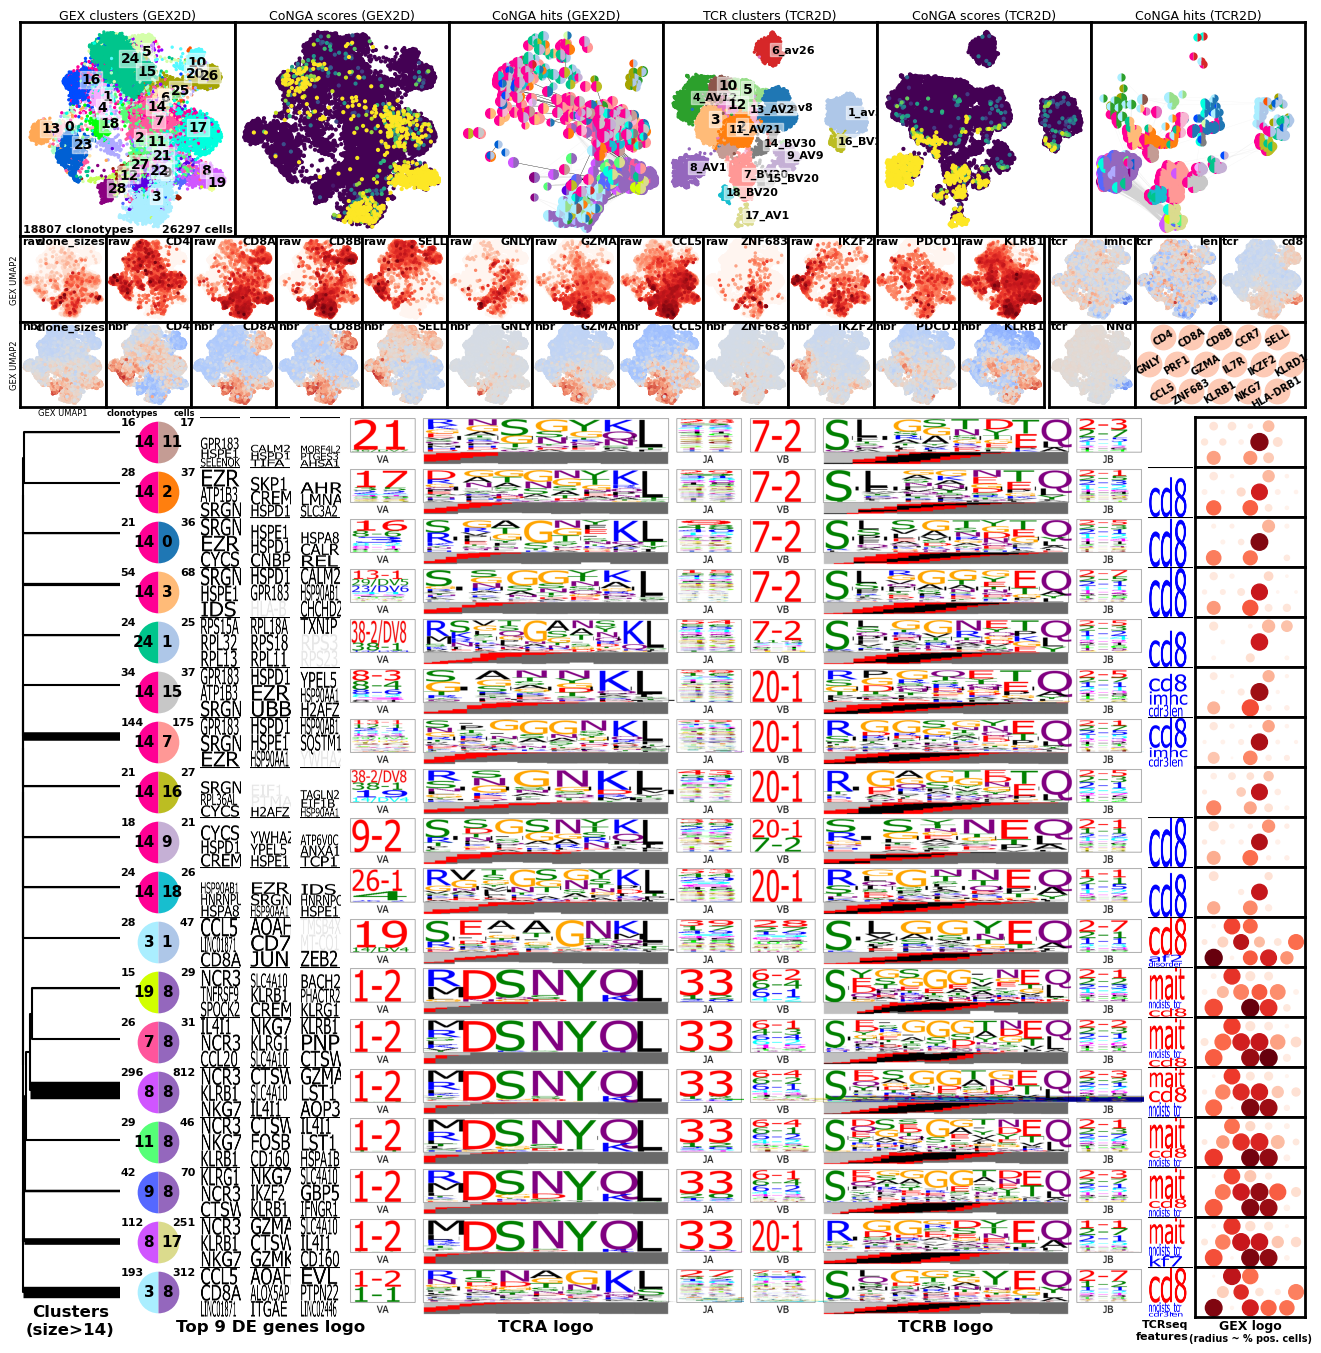

In [116]:
os.chdir(r'C:\Users\andre\revision\result')
nbrs_gex, nbrs_tcr = all_nbrs[0.01]

min_cluster_size = 15
conga.plotting.make_graph_vs_graph_logos(
    adata_ab,
    '0828_'+outfile_prefix,
    min_cluster_size,
    nbrs_gex,
    nbrs_tcr,
    custom_GEX_colormap = GEX_color_array,
    custom_GEX_colormap_dict = GEX_color_dict
)

In [51]:
adata_ab

AnnData object with n_obs × n_vars = 18807 × 1215
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'va', 'ja', 'vb', 'jb', 'clone_code', 'subject_id', 'clone_id', 'cdr3a_nucseq', 'cdr3b_nucseq', 'clusters_gex', 'percent_mito', 'sample_id', '_scvi_batch', '_scvi_labels', 'clone_sizes', 'gex_variation', 'leiden_gex', 'leiden_tcr', 'clusters_tcr', 'nndists_gex', 'nndists_tcr', 'is_invar

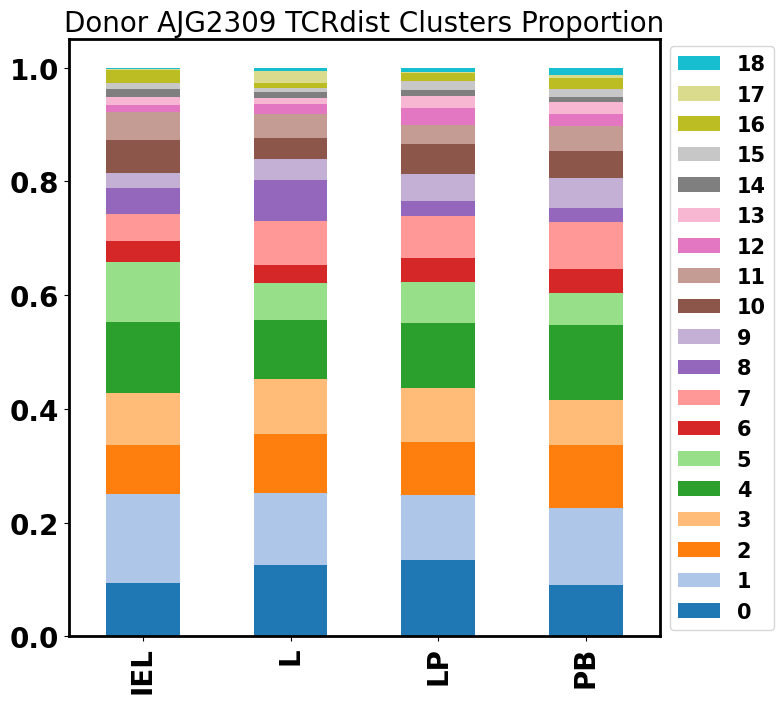

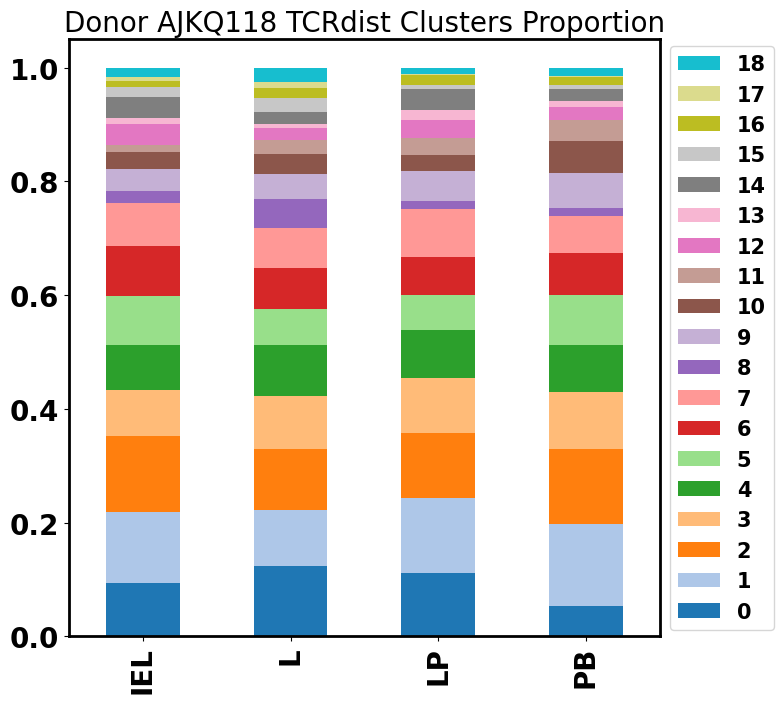

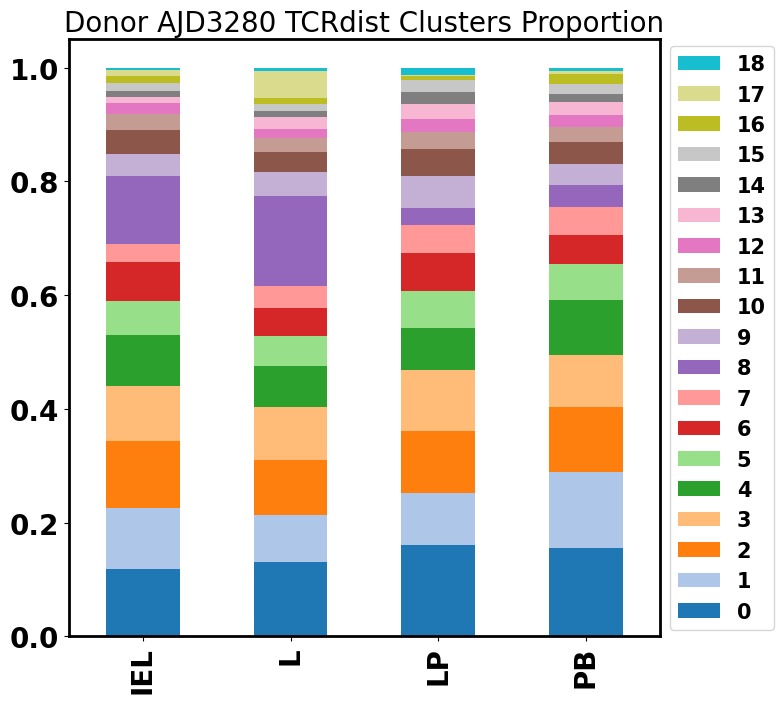

In [117]:
plt.rcParams['figure.figsize'] = [8,7.2]
cat_order = adata_ab.obs['clusters_tcr'].astype("category").values.categories
MAIT_frac = dict()
gammadelta_frac = dict()
cmap = plt.get_cmap('tab20')
clusters = np.array(adata_ab.obs['clusters_tcr'])
tcr_cluster_colors =  cmap.colors
for j in set(adata_ab.obs['Donor ID']):
    expand_subtype = pd.DataFrame()
    adata_temp = adata_ab[adata_ab.obs['Donor ID'] == j,:]
    for i in set(adata_ab.obs['tissue']):
        pdtemp = pd.DataFrame(adata_temp[adata_temp.obs['tissue'] == i,:].obs['clusters_tcr'].value_counts(normalize = True))
        pdtemp = pdtemp.rename({'proportion': i }, axis='columns')
        expand_subtype = pd.concat([expand_subtype, pdtemp], ignore_index=False, axis=1)
    expand_subtype = expand_subtype.reindex(index =cat_order)
    expand_subtype.transpose().plot.bar(stacked=True,color = tcr_cluster_colors,fontsize = 20 ).legend(loc='center left',bbox_to_anchor=(1.0, 0.5),fontsize = 15,reverse=True)
    plt.title(label = j +' TCRdist Clusters Proportion', fontsize = 20)
    plt.tight_layout()
    # plt.savefig(j+' Major celltype breakdown in tissues.png',dpi = 300)

C:\Users\andre\AppData\Local\Temp\ipykernel_23948\377005691.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_ab.obs.groupby('tissue+celltype')['conga_score_reverted'].mean().sort_values().plot.bar()


<Axes: xlabel='tissue+celltype'>

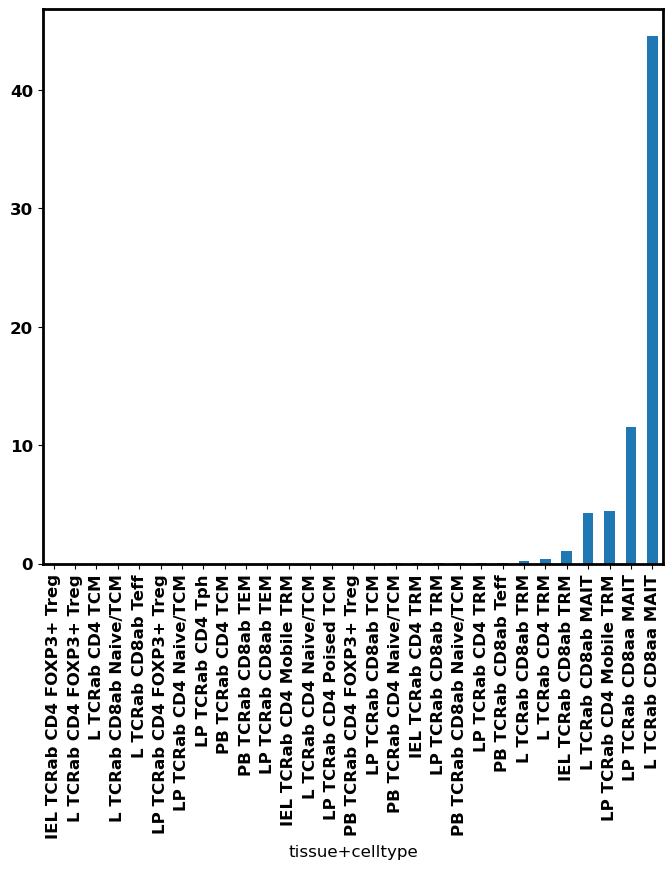

In [121]:
# Note that Conga essentially reduce to 1 cell 1 clonotype
# so the celltype of the cell who got assigned to that clone is not necessarily representative of all celltypes in that clone
conga_score_reverted = np.array([max(0, -1*np.log10(x)) for x in adata_ab.obs['conga_scores']]) #significance at 1/18806
adata_ab.obs['conga_score_reverted'] = conga_score_reverted
adata_ab.obs.groupby('tissue+celltype')['conga_score_reverted'].mean().sort_values().plot.bar()
# plt.yscale('log')

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_conga_hits(adata, all_nbrs, nbr_fracs, gex_colors,tcr_colors,markersize_coeff = 2, #min_cluster_size = 15,
    draw_edges_between_conga_hits = True,
    ignore_tcr_cluster_colors = False,
    show_real_clusters_gex = False,
    pretty = True, conga_scores_name= 'CoNGA', proj_tag = 'GEX TCR'
):
    nbrs_gex, nbrs_tcr = all_nbrs[ max(nbr_fracs) ]

    adata.obsm['nbrs_gex'] = nbrs_gex
    adata.obsm['nbrs_tcr'] = nbrs_tcr
    
    # adata = adata[adata.obs['clone_sizes']>= min_cluster_size]
    
    clusters_gex = adata.obs['clusters_gex']
    clusters_tcr = adata.obs['clusters_tcr']
    conga_scores = adata.obs['conga_scores']
    good_score_mask = np.array(conga_scores) <= 1.0
    X_gex_2d = adata.obsm['X_gex_2d']
    # X_tcr_2d = adata.obsm['X_tcr_2d']
    
    # nbrs_gex = adata.obsm['nbrs_gex']
    # nbrs_tcr = adata.obsm['nbrs_tcr'] 

    node2cluspair = {
        i:(x,y) for i,(x,y,m) in enumerate(zip(clusters_gex,
                                                clusters_tcr,
                                                good_score_mask)) if m} #all cells (that passed threshold), the index of cell: (its gex cluster, its tcr cluster) if conga score is high enough
    cluspair2nodes = {}
    for node, clp in node2cluspair.items(): #clp probably stands for cluster pairs
        cluspair2nodes.setdefault(clp,[]).append(node) #reverse,now it is what pais have which cells/nodes

    all_dbl_nbrs = {}
    for ii in node2cluspair:
        gex_nbrs = frozenset( nbrs_gex[ii]) #get cell ii's gex neighbors
        all_dbl_nbrs[ii] = [ x for x in nbrs_tcr[ii]
                                if good_score_mask[x] and x in gex_nbrs ] #both the gex and tcr neighbors for cell ii, I think

    all_xy_gex = { i:xy for i,xy in enumerate(X_gex_2d) }

    icol = 0
    # Draw edges
    intra_lines = []
    inter_lines = []
    seen_line = set()
    for ii in node2cluspair:
        for jj in all_dbl_nbrs[ii]: #jj is one of the ii cell's double-sided neighbors
            if (jj, ii) not in seen_line:
                seen_line.add((ii, jj))
                line = [[all_xy_gex[ii][0], all_xy_gex[ii][1]], [all_xy_gex[jj][0], all_xy_gex[jj][1]]]
                if node2cluspair[ii] == node2cluspair[jj]: #if jj and ii are in the same tcr cluster and gex cluster, draw a dark line between them
                    intra_lines.append(line)
                else:# well neighbor does not necessarily mean same cluster
                    inter_lines.append(line)

    if draw_edges_between_conga_hits:
        light_gray = "#4F4F4F"
        line_segments = LineCollection(inter_lines, linewidths=0.8, zorder=1, colors=light_gray, alpha=0.05)
        plt.gca().add_collection(line_segments)

        # dark_gray = '#888888'
        # line_segments = LineCollection(intra_lines, linewidths=0.25, zorder=1, colors='k')
        # plt.gca().add_collection(line_segments)

    # Plot nodes
    for clp, nodes in cluspair2nodes.items():
        xvals = np.array([all_xy_gex[x][0] for x in nodes])
        yvals = np.array([all_xy_gex[x][1] for x in nodes])
        cscores = np.array([conga_scores[x] for x in nodes])

        if ignore_tcr_cluster_colors:
            plt.plot(xvals, yvals,
                     zorder=2,
                     marker='o',
                     linestyle='None',
                     color=gex_colors[clp[0]],
                     markeredgecolor='none',
                     markeredgewidth=0)
        else:
            for score_threshold, markersize in [[1., 6], [1e-1, 7], [1e-2, 8]]:
                mask = cscores <= score_threshold
                if np.sum(mask) == 0:
                    continue
                reorder = np.argsort(cscores[mask])[::-1]
                left_color = 'none' if show_real_clusters_gex else gex_colors[clp[0]]
                plt.plot(xvals[mask][reorder], yvals[mask][reorder],
                         zorder=2,
                         marker='o',
                         linestyle='None',
                         markersize=markersize*markersize_coeff,
                         color=left_color,
                         markerfacecoloralt=tcr_colors[clp[1]],
                         fillstyle='left',
                         markeredgecolor='none',
                         markeredgewidth=0)

    # Formatting
    plt.xticks([], [])
    plt.yticks([], [])
    # plt.xlim((xmin, xmax))
    # plt.ylim((ymin, ymax))

    if pretty:
        plt.title(f'{conga_scores_name} hits', fontsize=20, fontweight = 'bold', pad=1)
        plt.xlabel(f'{proj_tag} UMAP1', fontweight = 'bold', fontsize=15) #, labelpad=1
    else:
        plt.title(f'{conga_scores_name} hits ({proj_tag}2D)',fontweight = 'bold',  fontsize=20, pad=1)

C:\Users\andre\AppData\Local\Temp\ipykernel_23948\3222933675.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cscores = np.array([conga_scores[x] for x in nodes])


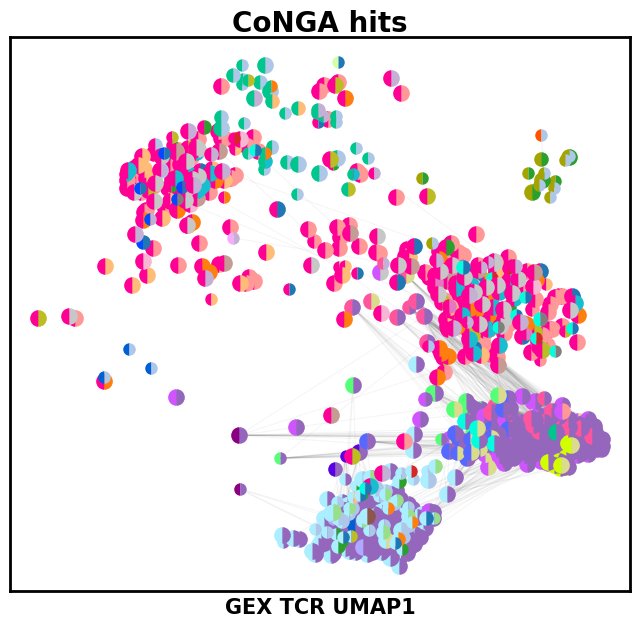

In [127]:
plot_conga_hits(adata_ab,all_nbrs, nbr_fracs, GEX_color_dict, cmap.colors,markersize_coeff = 1.5)#,min_cluster_size=15)

In [130]:
def plot_conga_hits_intra(adata, all_nbrs, nbr_fracs, gex_colors,tcr_colors,markersize_coeff = 2, #min_cluster_size = 15,
    draw_edges_between_conga_hits = True,
    ignore_tcr_cluster_colors = False,
    show_real_clusters_gex = False,
    pretty = True, conga_scores_name= 'CoNGA', proj_tag = 'GEX TCR'
):
    nbrs_gex, nbrs_tcr = all_nbrs[ max(nbr_fracs) ]

    adata.obsm['nbrs_gex'] = nbrs_gex
    adata.obsm['nbrs_tcr'] = nbrs_tcr
    
    # adata = adata[adata.obs['clone_sizes']>= min_cluster_size]
    
    clusters_gex = adata.obs['clusters_gex']
    clusters_tcr = adata.obs['clusters_tcr']
    conga_scores = adata.obs['conga_scores']
    good_score_mask = np.array(conga_scores) <= 1.0
    X_gex_2d = adata.obsm['X_gex_2d']
    # X_tcr_2d = adata.obsm['X_tcr_2d']
    
    # nbrs_gex = adata.obsm['nbrs_gex']
    # nbrs_tcr = adata.obsm['nbrs_tcr'] 

    node2cluspair = {
        i:(x,y) for i,(x,y,m) in enumerate(zip(clusters_gex,
                                                clusters_tcr,
                                                good_score_mask)) if m} #all cells (that passed threshold), the index of cell: (its gex cluster, its tcr cluster) if conga score is high enough
    cluspair2nodes = {}
    for node, clp in node2cluspair.items(): #clp probably stands for cluster pairs
        cluspair2nodes.setdefault(clp,[]).append(node) #reverse,now it is what pais have which cells/nodes

    all_dbl_nbrs = {}
    for ii in node2cluspair:
        gex_nbrs = frozenset( nbrs_gex[ii]) #get cell ii's gex neighbors
        all_dbl_nbrs[ii] = [ x for x in nbrs_tcr[ii]
                                if good_score_mask[x] and x in gex_nbrs ] #both the gex and tcr neighbors for cell ii, I think

    all_xy_gex = { i:xy for i,xy in enumerate(X_gex_2d) }

    icol = 0
    # Draw edges
    intra_lines = []
    inter_lines = []
    seen_line = set()
    for ii in node2cluspair:
        for jj in all_dbl_nbrs[ii]: #jj is one of the ii cell's double-sided neighbors
            if (jj, ii) not in seen_line:
                seen_line.add((ii, jj))
                line = [[all_xy_gex[ii][0], all_xy_gex[ii][1]], [all_xy_gex[jj][0], all_xy_gex[jj][1]]]
                if node2cluspair[ii] == node2cluspair[jj]: #if jj and ii are in the same tcr cluster and gex cluster, draw a dark line between them
                    intra_lines.append(line)
                else:# well neighbor does not necessarily mean same cluster
                    inter_lines.append(line)

    if draw_edges_between_conga_hits:
        light_gray = "#505050"
        line_segments = LineCollection(intra_lines, linewidths=0.8, zorder=1, colors=light_gray, alpha=0.05)
        plt.gca().add_collection(line_segments)

        # dark_gray = '#888888'
        # line_segments = LineCollection(intra_lines, linewidths=0.25, zorder=1, colors='k')
        # plt.gca().add_collection(line_segments)

    # Plot nodes
    for clp, nodes in cluspair2nodes.items():
        xvals = np.array([all_xy_gex[x][0] for x in nodes])
        yvals = np.array([all_xy_gex[x][1] for x in nodes])
        cscores = np.array([conga_scores[x] for x in nodes])

        if ignore_tcr_cluster_colors:
            plt.plot(xvals, yvals,
                     zorder=2,
                     marker='o',
                     linestyle='None',
                     color=gex_colors[clp[0]],
                     markeredgecolor='none',
                     markeredgewidth=0)
        else:
            for score_threshold, markersize in [[1., 6], [1e-1, 7], [1e-2, 8]]:
                mask = cscores <= score_threshold
                if np.sum(mask) == 0:
                    continue
                reorder = np.argsort(cscores[mask])[::-1]
                left_color = 'none' if show_real_clusters_gex else gex_colors[clp[0]]
                plt.plot(xvals[mask][reorder], yvals[mask][reorder],
                         zorder=2,
                         marker='o',
                         linestyle='None',
                         markersize=markersize*markersize_coeff,
                         color=left_color,
                         markerfacecoloralt=tcr_colors[clp[1]],
                         fillstyle='left',
                         markeredgecolor='none',
                         markeredgewidth=0)

    # Formatting
    plt.xticks([], [])
    plt.yticks([], [])
    # plt.xlim((xmin, xmax))
    # plt.ylim((ymin, ymax))

    if pretty:
        plt.title(f'{conga_scores_name} hits', fontsize=20, fontweight = 'bold', pad=1)
        plt.xlabel(f'{proj_tag} UMAP1', fontweight = 'bold', fontsize=15) #, labelpad=1
    else:
        plt.title(f'{conga_scores_name} hits ({proj_tag}2D)',fontweight = 'bold',  fontsize=20, pad=1)

C:\Users\andre\AppData\Local\Temp\ipykernel_23948\2129074395.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cscores = np.array([conga_scores[x] for x in nodes])


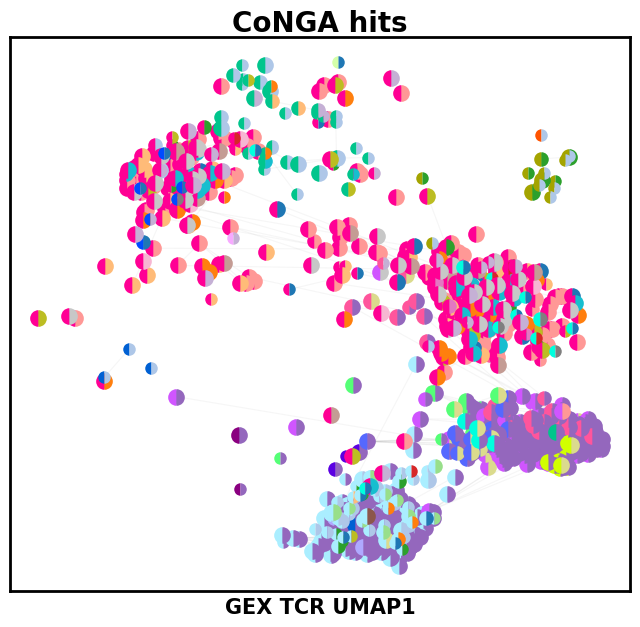

In [131]:
plot_conga_hits_intra(adata_ab,all_nbrs, nbr_fracs, GEX_color_dict, cmap.colors,markersize_coeff = 1.5)#,min_cluster_size=15)

In [56]:
def rgb_dict_to_hex(d):
    def rgb_to_hex(arr):
        # Accepts array-like of 4 floats (r,g,b,a), ignores alpha
        r, g, b = arr[:3]
        return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))
    return {k: rgb_to_hex(v) for k, v in d.items()}

# Example usage:
color_dict_hex = rgb_dict_to_hex(GEX_color_dict)
color_dict_hex

{0: '#ffaabf',
 1: '#f7aaff',
 2: '#aeaaff',
 3: '#aaeeff',
 4: '#aaffc8',
 5: '#d4ffaa',
 6: '#ffe3aa',
 7: '#ff559c',
 8: '#d055ff',
 9: '#5567ff',
 10: '#55f9ff',
 11: '#55ff77',
 12: '#c4ff55',
 13: '#ffa755',
 14: '#ff0093',
 15: '#8f00ff',
 16: '#004bff',
 17: '#00ffde',
 18: '#04ff07',
 19: '#d0ff00',
 20: '#ff5200',
 21: '#f000b8',
 22: '#5a00e1',
 23: '#0060d3',
 24: '#00c48b',
 25: '#1ab600',
 26: '#a4a300',
 27: '#991800',
 28: '#8a0080'}

In [132]:
adata_ab_copy = adata_ab.copy()
adata_ab_copy.obsm['X_umap'] = adata_ab_copy.obsm['X_gex_2d']
adata_ab_copy.obs['clusters_gex'] = adata_ab_copy.obs['clusters_gex'].astype("category").cat.reorder_categories(GEX_color_dict.keys())

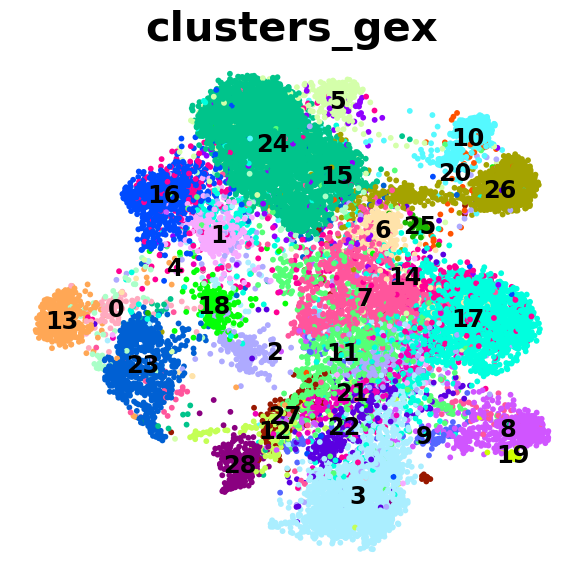

In [133]:
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['figure.figsize'] = [6,6]

plt.close()
fig = sc.pl.umap(adata_ab_copy, color = ['clusters_gex'],legend_loc = 'on data',frameon = False,
                 size = 70, ncols = 1,palette = list(color_dict_hex.values()),
                 return_fig = True, legend_fontsize = 'x-large')
ax = fig.get_axes()
for i in range(0,len(ax)):
    ax[i].xaxis.label.set_fontsize(22)
    ax[i].xaxis.label.set_fontweight('bold')
    ax[i].yaxis.label.set_fontsize(22)
    ax[i].title.set_fontsize(30)
    ax[i].yaxis.label.set_fontweight('bold')
    ax[i].title.set_fontweight('bold')

plt.tight_layout()
# plt.savefig('donor.png',dpi = 300,bbox_inches='tight')

In [134]:
adata_ab_copy = adata_ab_copy[adata_ab_copy.obs['conga_scores'] <= 1, :]

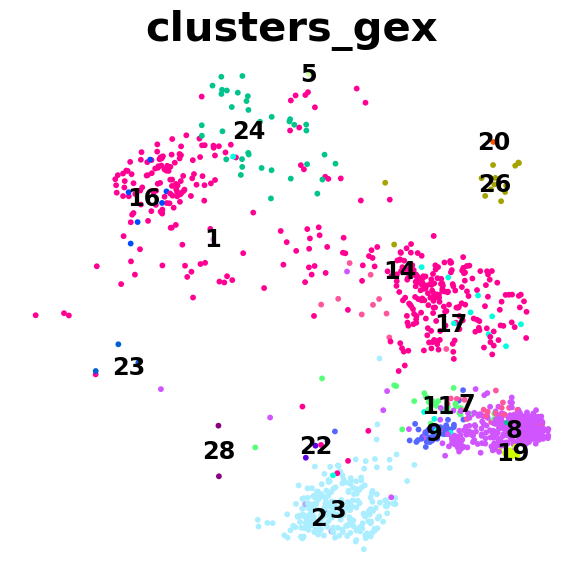

In [135]:
plt.close()
fig = sc.pl.umap(adata_ab_copy, color = ['clusters_gex'],legend_loc = 'on data',frameon = False,
                 size = 70, ncols = 1,
                 return_fig = True, legend_fontsize = 'x-large')
ax = fig.get_axes()
for i in range(0,len(ax)):
    ax[i].xaxis.label.set_fontsize(22)
    ax[i].xaxis.label.set_fontweight('bold')
    ax[i].yaxis.label.set_fontsize(22)
    ax[i].title.set_fontsize(30)
    ax[i].yaxis.label.set_fontweight('bold')
    ax[i].title.set_fontweight('bold')

plt.tight_layout()